# BenchmarkResults Filtering Workflow (Production-Oriented)

This notebook demonstrates the updated `filter_results` behavior:

- Filtering is **global across all submissions** in `openfe_benchmarks/results`.
- Return values are `BenchmarkResults` objects for matching submissions.
- Entry-level filters (for `dg`/`ddg`) still work, but selection happens at submission level.
- When using `load_results=False`, you can load a specific submission later with `load_raw_results()`.

The workflow below uses practical checks that are useful for CI and analysis pipelines, with assertions that fail fast when behavior changes.

In [1]:
from pathlib import Path

from cinnabar import plotting

from openfe_benchmarks.results._benchmark_results import filter_results


def submission_ids(items):
    return {item.submission_id for item in items}


def flatten(items):
    for item in items:
        if isinstance(item, list):
            yield from flatten(item)
        else:
            yield item


def get_nested(obj, path):
    value = obj
    for part in path.split("__"):
        if isinstance(value, dict):
            value = value.get(part)
        elif isinstance(value, list):
            next_values = []
            for entry in value:
                if isinstance(entry, dict):
                    nested = entry.get(part)
                else:
                    nested = getattr(entry, part, None)
                if nested is not None:
                    next_values.append(nested)
            value = next_values if next_values else None
        else:
            value = getattr(value, part, None)
        if value is None:
            return None
    return value

In [21]:
all_submissions = filter_results(load_results=False)

print(f"Total submissions discovered: {len(all_submissions)}")
print("Sample IDs:\n   ", "\n    ".join(sorted(submission_ids(all_submissions))))

assert all_submissions, "Expected at least one submission in results directory"
assert all(hasattr(r, "submission_id") for r in all_submissions)

# With load_results=False, only metadata is loaded initially.
example_submission = all_submissions[0]
print(f"Before load_raw_results: raw_results is {example_submission.raw_results}")

# Load computational results later, only when needed.
example_submission.load_raw_results()
print(
    "After load_raw_results: raw_results loaded =",
    example_submission.raw_results is not None,
)

assert example_submission.raw_results is not None

Total submissions discovered: 8
Sample IDs:
    2026-02-12_sage_230_jacs_set
    2026-03-18-openmm-840-qa-testing
    2026-06-22-tyk2-alchemicalarchive-test
    2026-08-04-openff3.0.0-alpha1b_opc3-jacs
    2026-08-05-openff3.0.0-alpha1b_tip3p-jacs
    2026-08-06-openff-2.3.0-solvation_set_freesolv
    2026_08_05_ff14sb_openff-3.0.0-alpha1b_tip3p_jacs_tyk2_thrombin
    2026_08_05_openff-3.0.0-alpha0_opc3_jacs
Before load_raw_results: raw_results is None
After load_raw_results: raw_results loaded = True


## 1) Production Metadata Filtering

These are fast, metadata-only queries (`load_results=False`) suitable for dashboards, CI checks, and release reports.

In [25]:
rbfe_submissions = filter_results(calculation_type="rbfe", load_results=False)
recent_submissions = filter_results(date=">=2026-01-01", load_results=False)
older_submissions = filter_results(date="<=2026-08-01", load_results=False)
newer_openfe_submissions = filter_results(openfe_version=">1.8.0", load_results=False)
non_test_submissions = filter_results(
    exclude_tags=["pontibus"], tags_mode="all", load_results=False
)

print(f"RBFE submissions: {len(rbfe_submissions)}")
print(f"Submissions since 2026-01-01: {len(recent_submissions)}")
print(f"Submissions on/before 2026-08-01: {len(older_submissions)}")
print(f"Submissions with openfe_version > 2.3.0: {len(newer_openfe_submissions)}")
print(f"Non-pontibus submissions: {len(non_test_submissions)}")

assert len(rbfe_submissions) <= len(all_submissions)
assert len(recent_submissions) <= len(all_submissions)
assert len(older_submissions) <= len(all_submissions)
assert len(newer_openfe_submissions) <= len(all_submissions)
assert len(non_test_submissions) <= len(all_submissions)

RBFE submissions: 7
Submissions since 2026-01-01: 8
Submissions on/before 2026-08-01: 3
Submissions with openfe_version > 2.3.0: 1
Non-pontibus submissions: 7


## 2) Entry-Level Filtering, Submission-Level Return

These queries inspect `dg`/`ddg` entries but return whole `BenchmarkResults` submissions. This is useful in production when downstream steps need both metadata and raw result context.

In [4]:
tyk2_related = filter_results(system_name="tyk2", load_results=True)

print(f"Submissions containing tyk2-like system names: {len(tyk2_related)}")
print("Example IDs:", sorted(submission_ids(tyk2_related))[:5])

assert isinstance(tyk2_related, list)
assert all(hasattr(r, "raw_results") for r in tyk2_related)

2026-08-19 13:20:41 - openfe_benchmarks.results._benchmark_results - WARNING - Skipping submission '2026-08-04-openff3.0.0-alpha1b_opc3-jacs' during filtering: Results file not found: /Users/jenniferclark/bin/openfe-benchmarks/openfe_benchmarks/results/2026-08-04-openff3.0.0-alpha1b_opc3-jacs/computational_results.json


Submissions containing tyk2-like system names: 6
Example IDs: ['2026-02-12_sage_230_jacs_set', '2026-03-18-openmm-840-qa-testing', '2026-06-22-tyk2-alchemicalarchive-test', '2026-08-05-openff3.0.0-alpha1b_tip3p-jacs', '2026_08_05_ff14sb_openff-3.0.0-alpha1b_tip3p_jacs_tyk2_thrombin']


## 3) Double-Underscore Filtering Demonstration

- A query with a real nested value returns submissions that actually exist.
- A query with an impossible nested value returns no submissions.

This is the production behavior you want when building search/reporting workflows.

In [14]:
# Positive case: concrete nested value that should exist.
chosen_key = "protocol_settings__protocol"
chosen_value = "RelativeHybridTopologyProtocol"
positive_result = filter_results(load_results=False, **{chosen_key: chosen_value})
positive_ids = submission_ids(positive_result)

# Negative case: concrete nested value that should not exist.
negative_result = filter_results(
    load_results=False, protocol_settings__protocol="ProtocolThatDoesNotExist"
)
negative_ids = submission_ids(negative_result)

print(f"Nested key used: {chosen_key}")
print(f"Existing value: {chosen_value}")
print(f"Existing-value matches: {len(positive_ids)}")
print("Sample matched IDs:", sorted(positive_ids)[:5])
print(f"Impossible-value matches: {len(negative_ids)}")

assert len(positive_ids) > 0, "Expected nested query to return existing submissions"
assert len(negative_ids) == 0, (
    "Expected impossible nested query to return no submissions"
)

Nested key used: protocol_settings__protocol
Existing value: RelativeHybridTopologyProtocol
Existing-value matches: 4
Sample matched IDs: ['2026-02-12_sage_230_jacs_set', '2026-03-18-openmm-840-qa-testing', '2026-06-22-tyk2-alchemicalarchive-test', '2026_08_05_ff14sb_openff-3.0.0-alpha1b_tip3p_jacs_tyk2_thrombin']
Impossible-value matches: 0


## 4) DG/DDG to Cinnabar Plot Demonstration

These examples show how filtered submissions feed directly into cinnabar plotting:

- DG plotting from ASFE submissions via `results.dg_femaps` and `plotting.plot_DGs`
- DDG plotting from RBFE submissions via `results.ddg_femaps` and `plotting.plot_DDGs`

Plots are written to a local `outputs/` directory.

### 4.1 DG Plot Example (ASFE)

Use a real ASFE submission and plot computed vs experimental DG values with cinnabar.

2026-08-19 13:27:04 - openfe_benchmarks.results._benchmark_results - WARNING - Skipping submission '2026-08-04-openff3.0.0-alpha1b_opc3-jacs' during filtering: Results file not found: /Users/jenniferclark/bin/openfe-benchmarks/openfe_benchmarks/results/2026-08-04-openff3.0.0-alpha1b_opc3-jacs/computational_results.json
2026-08-19 13:27:04 - openfe_benchmarks.results._benchmark_results - INFO - Computing FEMaps for dg results - first access may be slow
2026-08-19 13:27:04 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'freesolv' from benchmark set 'solvation_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: False.
  Found 0 ligand network files with keys: 


ASFE submission: 2026-08-06-openff-2.3.0-solvation_set_freesolv
System: solvation_set/freesolv
Saved DG plot: outputs/2026-08-06-openff-2.3.0-solvation_set_freesolv_solvation_set_freesolv_DG.png


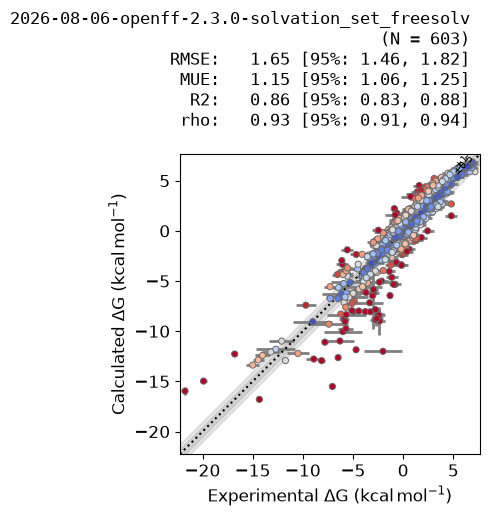

In [17]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

asfe_submission = filter_results(calculation_type="asfe", load_results=True)[0]

(system_group, system_name), dg_femap = next(iter(asfe_submission.dg_femaps.items()))

dg_plot_file = (
    output_dir / f"{asfe_submission.submission_id}_{system_group}_{system_name}_DG.png"
)
plotting.plot_DGs(
    dg_femap,
    source="Computational",
    title=asfe_submission.submission_id,
    figsize=5,
    scatter_kwargs={"s": 20, "marker": "o"},
    filename=dg_plot_file.as_posix(),
)

print(f"ASFE submission: {asfe_submission.submission_id}")
print(f"System: {system_group}/{system_name}")
print(f"Saved DG plot: {dg_plot_file}")

### 4.2 DDG Plot Example (RBFE)

Use a real RBFE submission and plot computed vs experimental DDG values with cinnabar.

2026-08-19 13:30:55 - openfe_benchmarks.results._benchmark_results - WARNING - Skipping submission '2026-08-04-openff3.0.0-alpha1b_opc3-jacs' during filtering: Results file not found: /Users/jenniferclark/bin/openfe-benchmarks/openfe_benchmarks/results/2026-08-04-openff3.0.0-alpha1b_opc3-jacs/computational_results.json
2026-08-19 13:30:55 - openfe_benchmarks.results._benchmark_results - INFO - Computing FEMaps for ddg results - first access may be slow
2026-08-19 13:30:55 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'jnk1' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_network
2026-08-19 13:30:55 - openfe_benchmarks.data._benchmark_systems - INFO - Loaded system 'thrombin' from benchmark set 'jacs_set' with:
  5 ligand file(s), and 0 cofactor file(s).
  Found protein file: True.
  Found 1 ligand network files with keys: industry_benchmarks_net

RBFE submission: 2026-02-12_sage_230_jacs_set
System: jacs_set/jnk1
DDG source used: ''
Saved DDG plot: outputs/2026-02-12_sage_230_jacs_set_jacs_set_jnk1_DDG.png


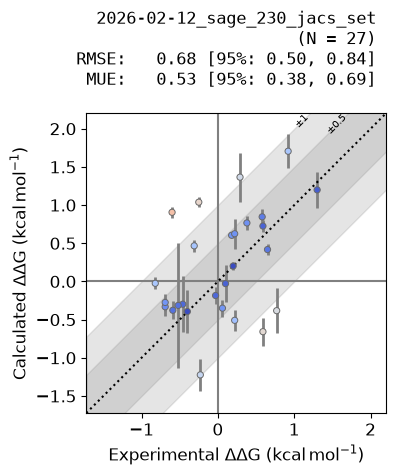

In [20]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

rbfe_submission = filter_results(calculation_type="rbfe", load_results=True)[0]
(system_group, system_name), ddg_femap = next(iter(rbfe_submission.ddg_femaps.items()))

relative_df = ddg_femap.get_relative_dataframe()
source = sorted(set(relative_df["source"].fillna("")))[0]

ddg_plot_file = (
    output_dir / f"{rbfe_submission.submission_id}_{system_group}_{system_name}_DDG.png"
)
plotting.plot_DDGs(
    ddg_femap,
    source=source,
    title=rbfe_submission.submission_id,
    figsize=5,
    scatter_kwargs={"s": 20, "marker": "o"},
    filename=ddg_plot_file.as_posix(),
)

print(f"RBFE submission: {rbfe_submission.submission_id}")
print(f"System: {system_group}/{system_name}")
print(f"DDG source used: {source!r}")
print(f"Saved DDG plot: {ddg_plot_file}")